# Feature Engineering

## Purpose of This Notebook

This notebook focuses on **feature engineering**, one of the most important steps in machine learning.

Feature engineering means creating stronger input variables that help the model make more accurate predictions. Even a strong machine learning model can perform poorly when the features are weak.

**Goal:** Improve prediction quality by creating business-focused features that support better demand and revenue forecasting.

## 1. Import Required Libraries

In this step, we import the libraries needed for feature engineering.

### Libraries Used

- `pandas`: handles dataset tables
- `numpy`: supports numerical operations
- `matplotlib` and `seaborn`: create charts and visualizations
- `joblib`: saves encoders, scalers, and models
- `warnings`: hides unnecessary warning messages

### Machine Learning Tools

- `LabelEncoder`: converts text values, such as category and product ID, into numbers
- `StandardScaler`: normalizes feature values
- `RandomForestRegressor`: checks feature importance

This step prepares the notebook for the full feature engineering process.

In [1]:
# 1. IMPORT REQUIRED LIBRARIES

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import joblib

import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

plt.style.use("default")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Cleaned Dataset

We load the cleaned dataset created in Notebook 01: `new_cleaned_sales_dataset.csv`.

### This Dataset Already Contains

- Cleaned data
- Validated values
- Date features
- Rolling features
- Business validation columns

Next, we improve the dataset further for model training.

In [2]:
# 2. LOAD CLEANED DATASET

file_path = "../data/processed/new_cleaned_sales_dataset.csv"

df = pd.read_csv(file_path)

print("Cleaned dataset loaded successfully")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

# Preview dataset

df.head()

Cleaned dataset loaded successfully
Total Rows: 2371
Total Columns: 16


,date,product_id,product_name,category,unit_price,quantity_sold,revenue,month,day_of_week,day,year,week_of_year,is_weekend,rolling_avg_qty,previous_qty,calculated_revenue
0,2025-01-01,E001,13A Plug base (ACL),Electrical,650,11,7150,1,2,1,2025,1,0,11.000000,0.0,7150
1,2025-01-02,E001,13A Plug base (ACL),Electrical,650,6,3900,1,3,2,2025,1,0,8.500000,11.0,3900
2,2025-01-03,E001,13A Plug base (ACL),Electrical,650,8,5200,1,4,3,2025,1,0,8.333333,6.0,5200
3,2025-01-04,E001,13A Plug base (ACL),Electrical,650,11,7150,1,5,4,2025,1,1,8.333333,8.0,7150
4,2025-01-07,E001,13A Plug base (ACL),Electrical,650,18,11700,1,1,7,2025,2,0,12.333333,11.0,11700


## 3. Dataset Review

We quickly inspect the dataset before creating new features.

### Review Checks

- Number of rows
- Number of columns
- Available features
- Missing values

This confirms that the dataset is ready for advanced feature engineering.

In [3]:
# 3. DATASET REVIEW

print("Dataset Information:\n")
df.info()
print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                2371 non-null   str    
 1   product_id          2371 non-null   str    
 2   product_name        2371 non-null   str    
 3   category            2371 non-null   str    
 4   unit_price          2371 non-null   int64  
 5   quantity_sold       2371 non-null   int64  
 6   revenue             2371 non-null   int64  
 7   month               2371 non-null   int64  
 8   day_of_week         2371 non-null   int64  
 9   day                 2371 non-null   int64  
 10  year                2371 non-null   int64  
 11  week_of_year        2371 non-null   int64  
 12  is_weekend          2371 non-null   int64  
 13  rolling_avg_qty     2371 non-null   float64
 14  previous_qty        2371 non-null   float64
 15  calculated_revenue  2371 non-null   int64  


## 4. Lag Features

Lag features help the model understand historical sales behavior.

**Example:** Yesterday's sales can help explain today's sales.

### Features Created

- `lag_1`: previous day sales
- `lag_2`: sales from two days earlier

These features are useful for demand forecasting, especially in time-based prediction systems.

In [4]:
# 4. CREATE LAG FEATURES

df = df.sort_values(["product_id", "date"])

df["lag_1"] = (

    df.groupby("product_id")["quantity_sold"]

    .shift(1)

    .fillna(0)

)

df["lag_2"] = (

    df.groupby("product_id")["quantity_sold"]

    .shift(2)

    .fillna(0)

)

print("Lag features created successfully")

Lag features created successfully


## 5. Rolling Features Enhancement

We improve the existing rolling features by using larger time windows.

### Features Created

- `rolling_avg_7`: 7-day average sales
- `rolling_avg_30`: 30-day average sales

### Patterns Captured

- Short-term trends
- Long-term sales behavior

These features improve forecasting performance by helping the model understand recent and broader sales patterns.

In [5]:
# 5. ENHANCED ROLLING FEATURES

df["rolling_avg_7"] = (

    df.groupby("product_id")["quantity_sold"]

    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())

)

df["rolling_avg_30"] = (

    df.groupby("product_id")["quantity_sold"]

    .transform(lambda x: x.rolling(window=30, min_periods=1).mean())

)

print("Enhanced rolling features created successfully")

Enhanced rolling features created successfully


## 6. Category Encoding

Machine learning models cannot directly understand text categories such as:

- Electrical
- Plumbing
- Oil

We convert categories into numeric values using **label encoding**.

### Example Encoding

- `Electrical -> 0`
- `Plumbing -> 1`
- `Oil -> 2`

This allows the model to use category information during training.

In [6]:
# 6. CATEGORY ENCODING

category_encoder = LabelEncoder()

df["category_encoded"] = category_encoder.fit_transform(df["category"])

print("Category encoding completed")

Category encoding completed


## 7. Product Encoding

We also encode `product_id` because product codes are stored as text values.

### Example Encoding

- `E001 -> 0`
- `P001 -> 5`

This improves demand prediction because different products can have different sales behavior.

In [7]:
# 7. PRODUCT ENCODING

product_encoder = LabelEncoder()

df["product_encoded"] = product_encoder.fit_transform(df["product_id"])

print("Product encoding completed")

# Save encoders

joblib.dump(category_encoder, "../models/category_label_encoder.pkl")

joblib.dump(product_encoder, "../models/product_label_encoder.pkl")

print("Encoders saved successfully")

Product encoding completed
Encoders saved successfully


## 8. Feature Selection

Not every column should be used for model training.

Some columns may:

- Add noise
- Reduce accuracy
- Cause overfitting

We select only the most useful predictive features.

### Example Selected Features

- `unit_price`
- `month`
- Rolling averages
- Lag values
- Previous quantity

Feature selection helps improve model performance and keeps the training dataset focused.

In [8]:
# 8. FEATURE SELECTION

feature_columns = [

    "product_encoded",
    "category_encoded",
    "unit_price",
    "month",
    "day",
    "day_of_week",
    "is_weekend",
    "rolling_avg_qty",
    "previous_qty",
    "lag_1",
    "lag_2",
    "rolling_avg_7",
    "rolling_avg_30"

]

print("Selected Features:\n")

for feature in feature_columns:

    print("-", feature)

Selected Features:

- product_encoded
- category_encoded
- unit_price
- month
- day
- day_of_week
- is_weekend
- rolling_avg_qty
- previous_qty
- lag_1
- lag_2
- rolling_avg_7
- rolling_avg_30


## 9. Feature Importance

We use machine learning to measure which features influence predictions the most.

**Example:** `quantity_sold` may be more important than `day_of_week`.

### Why This Matters

- Improves model explainability
- Improves presentation quality
- Helps justify model decisions

Feature importance is useful for both technical understanding and project evaluation.


Feature Importance:

             Feature  Importance
7    rolling_avg_qty    0.761327
10             lag_2    0.103472
8       previous_qty    0.053991
9              lag_1    0.049449
12    rolling_avg_30    0.007425
11     rolling_avg_7    0.006227
4                day    0.006149
3              month    0.004715
5        day_of_week    0.002986
0    product_encoded    0.002076
2         unit_price    0.001283
6         is_weekend    0.000484
1   category_encoded    0.000415


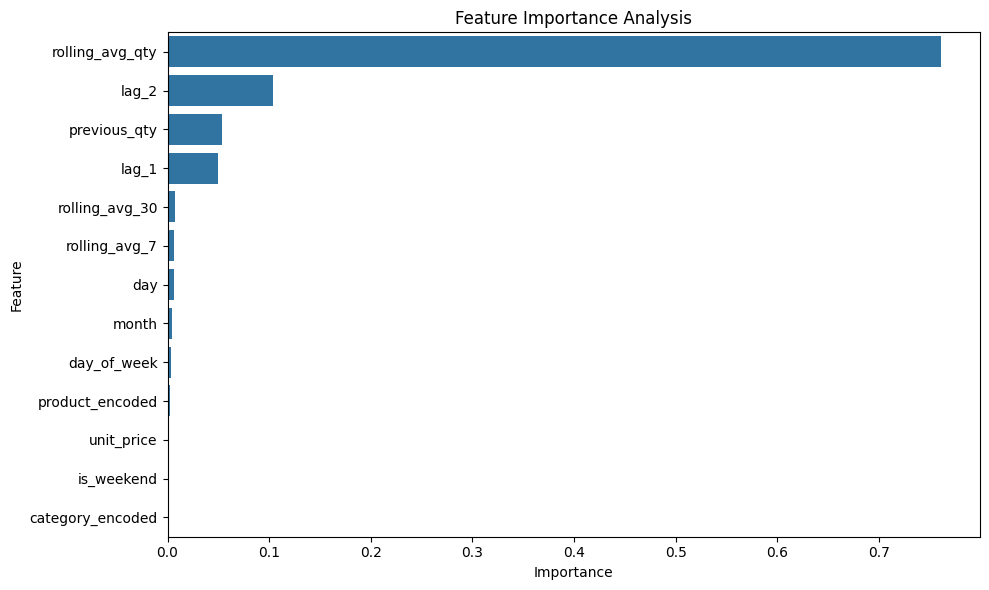

In [9]:
# 9. FEATURE IMPORTANCE ANALYSIS

X = df[feature_columns]

y = df["quantity_sold"]

model = RandomForestRegressor(

    n_estimators=100,

    random_state=42

)

model.fit(X, y)

importance_df = pd.DataFrame({

    "Feature": feature_columns,

    "Importance": model.feature_importances_

}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n")

print(importance_df)

plt.figure(figsize=(10, 6))

sns.barplot(

    data=importance_df,

    x="Importance",

    y="Feature"

)

plt.title("Feature Importance Analysis")

plt.tight_layout()

plt.show()

## 10. Scaling Strategy

Some machine learning models perform better when feature values are scaled.

### Example

- `unit_price = 1200`
- `is_weekend = 0`

Large differences in feature ranges can affect model behavior.

We use `StandardScaler` to normalize feature ranges.

This improves model stability and training quality.

In [10]:
# 10. SCALING STRATEGY

scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[feature_columns])

scaled_df = pd.DataFrame(

    scaled_features,

    columns=feature_columns

)

print("Feature scaling completed")

# Save scaler

joblib.dump(scaler, "../models/feature_scaler.pkl")

print("Scaler saved successfully")

Feature scaling completed
Scaler saved successfully


## 11. Final Feature Dataset

After all feature engineering steps, we save the final machine-learning-ready dataset.

### This Dataset Is Used For

- Model development
- Model validation
- Prediction pipeline

Saving this dataset creates a clean and professional machine learning workflow.

In [11]:
# 12. SAVE FINAL FEATURE DATASET AND FEATURE IMPORTANCE REPORT

importance_df.to_csv(

    "../reports/feature_importance.csv",

    index=False

)

print("Feature importance report saved")

final_output_path = "../data/processed/final_feature_engineered_dataset.csv"

df.to_csv(final_output_path, index=False)

print(f"Final feature engineered dataset saved to: {final_output_path}")

Feature importance report saved
Final feature engineered dataset saved to: ../data/processed/final_feature_engineered_dataset.csv
